#Setup

##Instalações de bibliotecas

In [37]:
!pip install streamlit --quiet

##Importação de bibliotecas instaladas

###Biliotecas de manipulação de dados

In [38]:
import pandas as pd
import numpy as np

###Biliotecas de plotagem de gráficos

In [39]:
import plotly.express as px

###Biblioteca de sistema

In [40]:
import io

###Biliotecas de dashboard

In [41]:
import streamlit as st

#Estabelecendo relacionamento com Github

Para isso precisaremos usar shell Bash (Linux) em vez de Python, para simular um terminal (que existe por exemplo no VS Code ou no Cloud Shell)

In [42]:
%%bash

set -e

# Pasta e permissões
mkdir -p ~/.ssh
chmod 700 ~/.ssh

# Gerar chave (se ainda não existir)
[ -f ~/.ssh/id_rsa ] || ssh-keygen -t rsa -b 4096 -C "gregorio.rodrigues@gmail.com" -f ~/.ssh/id_rsa -N ""

chmod 600 ~/.ssh/id_rsa
chmod 644 ~/.ssh/id_rsa.pub

# Serão geradas duas chaves: id_rsa → chave privada (fica no Colab/PC, nunca compartilhe). id_rsa.pub → chave pública (essa você pode colar no GitHub).
echo ">>> SUA CHAVE PÚBLICA:"
cat ~/.ssh/id_rsa.pub
echo "---------------------------------------------------------"

# Confiar no host do GitHub
ssh-keyscan -t rsa,ecdsa,ed25519 github.com >> ~/.ssh/known_hosts 2>/dev/null
chmod 644 ~/.ssh/known_hosts

>>> SUA CHAVE PÚBLICA:
ssh-rsa AAAAB3NzaC1yc2EAAAADAQABAAACAQDvUe29S2kSroNlXKPJtQ0rKf7eyqP1Kctnkz15lMGZoGZXjCRd5SQVDbCT+uXwLX+Tzh7EAT6AyX7VNW4wv4fma3r9bha+EYIscTduDKETa2kUgeu8synD0LqqpoICqcDnbjZEADKoom1kurlt0n0HIaycJrHw/oHz2tVCd7jJWNYioOUnZYXBEEFTQ7VF35gkeKnWHrtpMSroYZgxHu1eZG4IOdsuz0Wgd+c2oPWsBwB7MvfINiqQC5BSV4JVRvkUTb05Ymi+aEj0zSEUBRsBOhXUOLeynBudjYrUkcbEPHYRzXe2a9Mu3s3s/UkrSnli+p35rdotHl4jPUfA7i8MoHCdg2gsw1SJlklRzGtL12zR8yjmpaALdGmpj1bM5AlLLfLr6EACyqyg/L+FfqODOr1b7nGc+KdhonH3MmJwGiKEQNZCs4oyq5xgl0JHdsY6TfPjhO3IKFKLIY4AtL76NjSaEJVIV3LvN8CM/+jhijq0X/gJVMRJC+7MSH3bNl1oWdZeVkBEniMpBpIO2zDHYIYc8jK6/AGXZqgFZV6dzqU9FCVQvoaMEybRpaTE6LxY8aKb/Bfx1ttdtmxyW45iPkabPyHmBKomP0JgfkCo0JkK8xKPiH0erOkzhHQdCAwsqxaSDhckcOoket7rvn9KBebLH/C4qd5tnKRtFZMDuw== gregorio.rodrigues@gmail.com
---------------------------------------------------------


Vá em GitHub → Settings → SSH and GPG keys. Clique em New SSH key. Cole todo o conteúdo do arquivo id_rsa.pub (começa com ssh-rsa e termina com o e-mail). Dê um nome (ex.: Colab Notebook). Salve.

In [43]:
%%bash

# Testar conexão dentro do mesmo processo
ssh-agent bash -lc "ssh-add ~/.ssh/id_rsa && ssh -T git@github.com || true"

Identity added: /root/.ssh/id_rsa (gregorio.rodrigues@gmail.com)
Hi gregrodrigues22! You've successfully authenticated, but GitHub does not provide shell access.


#Criação do APP simples de exemplo

In [44]:
%%writefile app.py
import streamlit as st, pandas as pd
st.set_page_config(page_title="Meu App", layout="wide")
st.title("🚀 App Streamlit publicado via GitHub")
st.write("Edite `app.py` e faça `git push` para atualizar o app!!")
st.write("Exemplo de DF:")
st.dataframe(pd.DataFrame({"A":[1,2,3],"B":[4,5,6]}))

Writing app.py


In [47]:
%%writefile requirements.txt
numpy
pandas
plotly
streamlit==1.32.2
altair==4.2.2

Overwriting requirements.txt


In [49]:
%%writefile .gitignore
.ipynb_checkpoints/
__pycache__/
*.pyc
*.log
.env
.config/
sample_data/

Overwriting .gitignore


In [51]:
#%%writefile runtime.txt
#python-3.11

#Antes, um entendimento rápido do Github

### **Diferenciação entre Git e Github:**

* Git: sistema local que versiona arquivos, o “histórico de versões” do seu projeto, na sua máquina.

* GitHub: serviço na nuvem que hospeda repositórios Git e adiciona colaboração, a “nuvem” onde você guarda e compartilha esse histórico com outras pessoas.

### **As áreas do Git**

* Workspace = sua pasta (você edita os arquivos).
* Local Repository = seu histórico salvo (commits).
* Remote Repository (GitHub) = a nuvem, onde você compartilha.

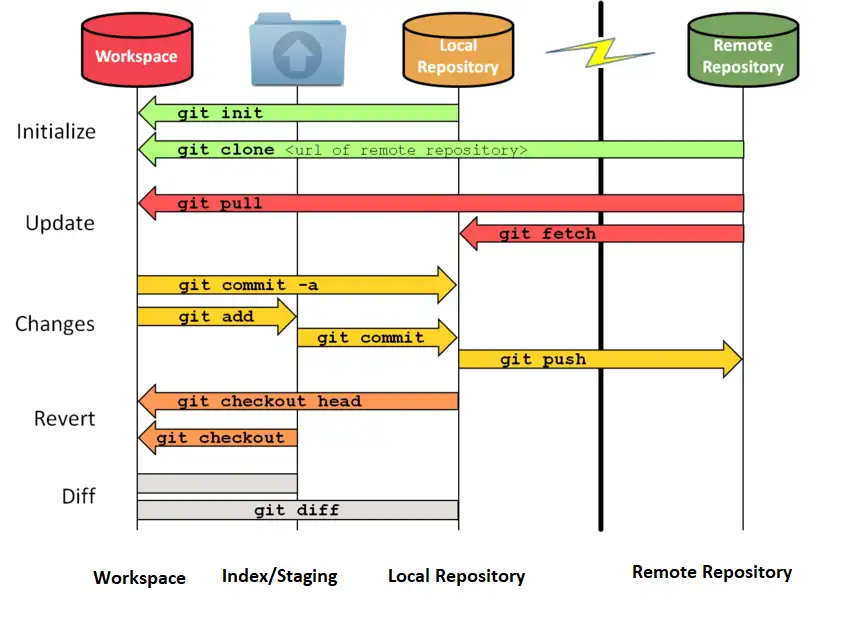

### **Ações para trânsito de arquivos entre as áreas**

Novo projeto local? → git init

* git init — inicializar um repositório
  * Quando usar: se você tem uma pasta de projeto nova (ainda sem Git) e quer colocar o Git para versionar.
  * O que faz: cria uma pasta escondida chamada .git/ que guarda todo o histórico e configurações.
  * Exemplo:

Projeto que já existe no GitHub? → git clone

* git clone — baixar do GitHub para sua máquina
  * Quando usar: primeira vez que você vai trabalhar num projeto que já existe no GitHub.
  * O que faz: cria uma pasta com todos os arquivos e o histórico.
  * Exemplo: git clone https://github.com/usuario/projeto.git

Quer atualizar o projeto local com mudanças possíveis no Github? → git pull

* git pull — trazer as novidades do GitHub
  * Quando usar: antes de começar a editar (e também antes de dar push).
  * O que faz: baixa os commits novos do GitHub e junta com o seu código.
  * Exemplo: git pull
  * Se aparecer “conflito”, abra os arquivos marcados, escolha a versão certa, salve e faça um commit.

Acabou de editar? → git add

* git add
  * Quando usar: depois que você editou/criou arquivos e antes de fazer o commit.
  * O que faz: coloca os arquivos escolhidos numa “sacola de preparo” chamada staging area (ou “index”). É como dizer: “quero que essas mudanças entrem na próxima foto (commit)”.
  * Como fazer: git add arquivo.txt (adiciona só esse arquivo), git add .      (adiciona todas as mudanças da pasta atual)

Separou o que subir e quer preparar a subida? → git commit

* git commit
  * Quando usar: depois de editar arquivos.
  * O que faz: tira uma “foto” do estado atual e guarda no histórico local.
  * Como fazer (jeito simples): git commit -m "mensagem explicando o que mudou"

Tudo preparado, quer subir para a nuvem? → git push

* git push
  * Quando usar: depois de fazer um ou mais commits e querer compartilhar/backup.
  * O que faz: envia seus commits locais para o repositório remoto no GitHub.
  * Como fazer: git push

### **Versionamento**

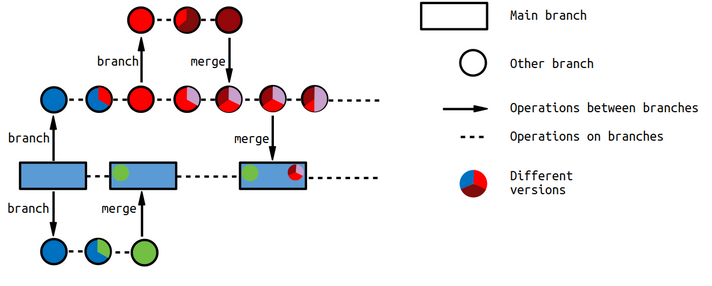

* Linha principal (main) vai recebendo commits (bolinhas vermelhas).
* Em certos pontos, alguém cria uma branch (ramo paralelo). Exemplo: a bolinha azul sai da linha principal e começa um caminho próprio.
* Nessa branch, a pessoa faz vários commits (bolinhas azuis/verdes).
* Esses commits não afetam a main enquanto estiverem separados.
* Depois, quando o trabalho está pronto, essa branch é juntada de volta na principal (merge), representado pelo círculo meio a meio (mistura das cores).
* O ciclo pode se repetir: sempre que precisar trabalhar em algo novo/arriscado, cria-se uma branch, trabalha, e depois faz merge de volta.

### **Uma analogia**

As áreas na analogia:
* Workspace (sua pasta) → a galeria do celular: onde as fotos brutas ficam e você edita.
* Repositório local → o álbum de fotos salvo no celular, organizado com legenda e data.
* Repositório remoto (GitHub) → a nuvem de fotos (Google Photos / iCloud), onde você sobe seus álbuns para backup e compartilhar.

Os comandos na analogia
* git init → abrir um álbum novo no app para começar a guardar fotos.
* git clone → baixar um álbum inteiro já existente da nuvem para o celular.
* git add → marcar as fotos ⭐ que vão entrar no próximo álbum.
* git commit -m "..." → salvar essas fotos no álbum do celular, com legenda.
* git push → subir esse álbum para a nuvem.
* git pull → baixar álbuns atualizados da nuvem para o celular.
* branch → criar um álbum paralelo (ex.: “viagem com amigos”) para organizar diferente.
* merge / Pull Request → juntar esse álbum paralelo no álbum principal.

#Inicializar o repositório Git local (uma única vez)

In [52]:
%%bash

set -e #modo “fail-fast”: se qualquer comando abaixo falhar (retorno ≠ 0), a célula para imediatamente.
git init #cria um repositório Git vazio na pasta atual (/content/...). Ele gera o diretório oculto .git/.
git branch -M main #Forçar a branch para main (git branch -M main) serve para padronizar o nome da sua branch principal com o que o GitHub usa hoje por padrão.
git config user.email "gregorio.rodrigues@gmail.com" #grava, neste repositório, o e-mail que aparecerá nos commits. (Não é seu login do GitHub; serve para metadados do commit.)
git config user.name  "gregrodrigues22" #grava o nome do autor que aparecerá nos commits.
echo "OK: git inicializado e branch main criada." #só imprime uma mensagem de confirmação ao final.

Reinitialized existing Git repository in /content/.git/
OK: git inicializado e branch main criada.


In [53]:
%%bash

set -e #set -e: se algum comando falhar, a célula para.
URL_SSH="git@github.com:gregrodrigues22/app_aula_4.git" #URL_SSH=...: guarda a URL SSH do seu repositório no GitHub.

if git remote | grep -qx origin; then #git remote lista os remotos, verifica se existe o remoto chamado origin.
  echo "origin já existe → atualizando URL para SSH"
  git remote set-url origin "$URL_SSH" #Se já existe, ele atualiza a URL (set-url) para a forma SSH.
else
  echo "origin não existe → criando origin em SSH"
  git remote add origin "$URL_SSH" #Se não existe, ele cria o remoto origin apontando para a URL SSH.
fi

git remote -v   #Mostra os remotos configurados (linhas fetch e push).

origin já existe → atualizando URL para SSH
origin	git@github.com:gregrodrigues22/app_aula_4.git (fetch)
origin	git@github.com:gregrodrigues22/app_aula_4.git (push)


agora o origin usa SSH para buscar e enviar.

#Publicando para o git primeira vez

In [54]:
%%bash
# Verifique quais arquivos você tem
# Apenas confirma que app.py e requirements.txt existem no diretório /content.
ls -l

total 16
-rw-r--r-- 1 root root  295 Mar 26 00:01 app.py
-rw-r--r-- 1 root root   52 Mar 26 00:02 requirements.txt
-rw-r--r-- 1 root root   12 Mar 26 00:03 runtime.txt
drwxr-xr-x 1 root root 4096 Mar 23 13:29 sample_data


In [56]:
%%bash
# Adicionar os arquivos para publicar no github. Coloca os arquivos na “lista de preparação” para commit.
git add requirements.txt app.py .gitignore

In [57]:
%%bash
git status -s   # deve listar só o que foi adicionado

M  app.py


In [58]:
%%bash
# Fazer o comit para o git com uma mensagem
git commit -m "adiciona app.py e requirements.txt para deploy no Streamlit"

[main 8303ca7] adiciona app.py e requirements.txt para deploy no Streamlit
 1 file changed, 6 insertions(+), 164 deletions(-)
 rewrite app.py (100%)


Até aqui git commit, git add, git status, git init, etc. são operações locais, por isso não usam rede/SSH e não precisam de ssh-agent.

Já para para comandos que conversam com o GitHub é necessário utilizar o ssh-agent: git fetch, git pull, git push, git clone.

In [59]:
%%bash
# No primeiro push de uma branch você precisa dizer para onde ela vai, e o Git grava isso para os próximos pushes/pulls.
ssh-agent bash -lc "ssh-add ~/.ssh/id_rsa && git push -u origin main"

Branch 'main' set up to track remote branch 'main' from 'origin'.


Identity added: /root/.ssh/id_rsa (gregorio.rodrigues@gmail.com)
To github.com:gregrodrigues22/app_aula_4.git
 * [new branch]      main -> main


#Melhorias - colocando principais elementos do Streamlit

**Documentação**

https://docs.streamlit.io/develop

**Galeria de apps para copiar e se inspirar**

https://streamlit.io/gallery

In [60]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

# -------------------------
# Cria uma página
# -------------------------
st.set_page_config(page_title="Meu App", page_icon="🚀", layout="wide")

# -------------------------
# Cria o título e substítulos da página app
# -------------------------
st.title("App Streamlit publicado via GitHub")
st.caption("Edite `app.py` e faça `git push` para atualizar o app!")

# -------------------------
# Cria dados de exemplo
# -------------------------
@st.cache_data
def carregar_dados():
    dados = [
        {"data":"2025-07-01","unidade":"Hospital A","especialidade":"Clínica Geral","sexo":"F","idade":23,"tempo_espera_min":18,"satisfacao":4,"custo":120.0},
        {"data":"2025-07-01","unidade":"Hospital A","especialidade":"Cardiologia",  "sexo":"M","idade":67,"tempo_espera_min":35,"satisfacao":3,"custo":420.0},
        {"data":"2025-07-02","unidade":"Hospital A","especialidade":"Pediatria",    "sexo":"F","idade":9, "tempo_espera_min":12,"satisfacao":5,"custo":90.0},
        {"data":"2025-07-02","unidade":"Hospital B","especialidade":"Clínica Geral","sexo":"M","idade":41,"tempo_espera_min":22,"satisfacao":4,"custo":150.0},
        {"data":"2025-07-03","unidade":"Hospital B","especialidade":"Cardiologia",  "sexo":"F","idade":72,"tempo_espera_min":40,"satisfacao":3,"custo":500.0},
        {"data":"2025-07-03","unidade":"Hospital A","especialidade":"Ortopedia",    "sexo":"M","idade":35,"tempo_espera_min":28,"satisfacao":4,"custo":260.0},
        {"data":"2025-07-04","unidade":"Hospital A","especialidade":"Dermatologia", "sexo":"F","idade":29,"tempo_espera_min":15,"satisfacao":5,"custo":110.0},
        {"data":"2025-07-04","unidade":"Hospital B","especialidade":"Pediatria",    "sexo":"M","idade":6, "tempo_espera_min":10,"satisfacao":5,"custo":80.0},
        {"data":"2025-07-05","unidade":"Hospital B","especialidade":"Clínica Geral","sexo":"F","idade":53,"tempo_espera_min":26,"satisfacao":4,"custo":140.0},
        {"data":"2025-07-05","unidade":"Hospital A","especialidade":"Ortopedia",    "sexo":"M","idade":47,"tempo_espera_min":33,"satisfacao":3,"custo":300.0},
    ]
    df = pd.DataFrame(dados)
    df["data"] = pd.to_datetime(df["data"])
    return df

df = carregar_dados()

# -------------------------
# Filtros
# -------------------------

with st.sidebar:

    st.subheader("🔎 Filtros")

    # intervalo de datas sugerido pelo min/max do DF
    dmin, dmax = df["data"].min().date(), df["data"].max().date()
    f_data = st.date_input("Período", value=(dmin, dmax), min_value=dmin, max_value=dmax)

    # filtros categóricos (multiselect) com todas as opções pré-selecionadas
    f_unidade = st.multiselect("Unidade",
                               sorted(df["unidade"].unique().tolist()),
                               default=sorted(df["unidade"].unique().tolist()))

    f_esp = st.multiselect("Especialidade",
                           sorted(df["especialidade"].unique().tolist()),
                           default=sorted(df["especialidade"].unique().tolist()))

    f_sexo = st.multiselect("Sexo",
                            sorted(df["sexo"].unique().tolist()),
                            default=sorted(df["sexo"].unique().tolist()))

    # filtros numéricos (sliders com intervalo)
    f_idade = st.slider("Idade",
                        int(df["idade"].min()),
                        int(df["idade"].max()),
                        (int(df["idade"].min()), int(df["idade"].max())))

    f_espera = st.slider("Tempo de espera (min)",
                         int(df["tempo_espera_min"].min()),
                         int(df["tempo_espera_min"].max()),
                         (int(df["tempo_espera_min"].min()), int(df["tempo_espera_min"].max())))

    f_custo = st.slider("Custo (R$)",
                        float(df["custo"].min()),
                        float(df["custo"].max()),
                        (float(df["custo"].min()), float(df["custo"].max())))

# -------------------------
# Aplica filtro
# -------------------------

# Aplica os filtros construindo uma máscara booleana linha a linha.
mask = (
    (df["data"].between(pd.to_datetime(f_data[0]), pd.to_datetime(f_data[1])))
    & (df["unidade"].isin(f_unidade))
    & (df["especialidade"].isin(f_esp))
    & (df["sexo"].isin(f_sexo))
    & (df["idade"].between(f_idade[0], f_idade[1]))
    & (df["tempo_espera_min"].between(f_espera[0], f_espera[1]))
    & (df["custo"].between(f_custo[0], f_custo[1]))
)

# DataFrame filtrado (cópia para evitar avisos do pandas)
df_f = df[mask].copy()

# -------------------------
# KPIs
# -------------------------

c1, c2, c3, c4 = st.columns(4)

#len(): contagem de linhas sobre o filtrado
#mean()/sum(): agregações sobre o filtrado

c1.metric("Atendimentos", len(df_f))
c2.metric("Tempo médio de espera (min)", f"{df_f['tempo_espera_min'].mean():.1f}")
c3.metric("Satisfação média (1–5)", f"{df_f['satisfacao'].mean():.1f}")
c4.metric("Custo total (R$)", f"{df_f['custo'].sum():.2f}")

st.divider()

# -------------------------
# 4) Tabela / Gráfico / Download
# -------------------------

tab1, tab2, tab3 = st.tabs(["📋 Tabela", "📊 Gráfico", "⬇️ Exportar"])

with tab1: # Tabela responsiva com o DF filtrado
    st.dataframe(df_f, use_container_width=True, height=340)

with tab2:

    # Gráfico dinâmico:
    st.subheader("Gráfico por dimensão")

    # o usuário escolhe a dimensão (eixo X)
    dim = st.selectbox("Dimensão", ["especialidade", "unidade", "sexo", "data"])

    # e a métrica (agregação).
    met = st.selectbox("Métrica", ["Atendimentos", "Tempo médio de espera", "Custo total", "Satisfação média"])

    # groupby + size/mean/sum produzem o DataFrame 'agg' para plotar
    if met == "Atendimentos":
        agg = df_f.groupby(dim).size().reset_index(name="valor")
    elif met == "Tempo médio de espera":
        agg = df_f.groupby(dim)["tempo_espera_min"].mean().reset_index(name="valor")
    elif met == "Custo total":
        agg = df_f.groupby(dim)["custo"].sum().reset_index(name="valor")
    else:
        agg = df_f.groupby(dim)["satisfacao"].mean().reset_index(name="valor")

    # se a dimensão for data, faz linha temporal; caso contrário, barras.
    if dim == "data":
        fig = px.line(agg.sort_values(dim), x=dim, y="valor", markers=True)
    else:
        fig = px.bar(agg.sort_values("valor", ascending=False), x=dim, y="valor")
    fig.update_layout(height=420, margin=dict(l=10, r=10, t=30, b=10))
    st.plotly_chart(fig, use_container_width=True)

with tab3:

    ## Exporta o DF filtrado como CSV para download.
    st.download_button(
        "Baixar CSV filtrado",
        df_f.to_csv(index=False).encode("utf-8"),
        file_name="dados_saude_filtrados.csv",
        mime="text/csv",
    )

# Rodapé com shapes (linhas, colunas) do DF original e filtrado.
st.caption(f"Shape original: {df.shape} | filtrado: {df_f.shape}")

Overwriting app.py


#Publicando atualizações

In [63]:
%%bash
git add .
git commit -m "feat: exemplo saúde (10 linhas) + filtros, KPIs, gráfico e download" || echo "Nada novo"
ssh-agent bash -lc "ssh-add ~/.ssh/id_rsa && git push"

[main 192c4ed] feat: exemplo saúde (10 linhas) + filtros, KPIs, gráfico e download
 1 file changed, 38 insertions(+), 164 deletions(-)
 rewrite app.py (99%)


Identity added: /root/.ssh/id_rsa (gregorio.rodrigues@gmail.com)
To github.com:gregrodrigues22/app_aula_4.git
   4f20e5b..192c4ed  main -> main


In [ ]:
%%bash
git add .
git commit -m "feat: adiciona tela de login no app" || echo "Nada novo para commit"
ssh-agent bash -lc "ssh-add ~/.ssh/id_rsa && git push"


In [62]:
%%writefile app.py

import streamlit as st

def main():
    st.title("Tela de Login")

    menu = ["Login", "Registrar"]
    choice = st.sidebar.selectbox("Menu", menu)

    if choice == "Login":
        st.subheader("Acesse sua conta")

        username = st.sidebar.text_input("Usuário")
        password = st.sidebar.text_input("Senha", type='password')

        if st.sidebar.button("Entrar"): # Botão "Entrar" movido para a barra lateral
            if username == "admin" and password == "admin123": # Exemplo simples de credenciais
                st.success(f"Bem-vindo(a) {username}!")
                st.write("Você está logado.")
            else:
                st.warning("Usuário ou senha incorretos")

    elif choice == "Registrar":
        st.subheader("Crie uma nova conta")
        new_username = st.text_input("Nome de Usuário")
        new_password = st.text_input("Senha", type='password')
        confirm_password = st.text_input("Confirme a Senha", type='password')

        if st.button("Registrar"): # Botão "Registrar" no corpo principal
            if new_password == confirm_password:
                st.success("Sua conta foi criada com sucesso!")
                st.info("Agora você pode fazer login")
                # Aqui você adicionaria a lógica para salvar o novo usuário
            else:
                st.warning("As senhas não coincidem")

if __name__ == '__main__':
    main()

Overwriting app.py
